In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ThickLensFocalLenth=lambda R,nm,nl:R*nm/(nl-nm)

ThinLensFocalLength=lambda n1,n2,R1,R2:((n1/n2)-1)*((R1-R2)/(R1*R2))
ThickLensFocalLength=lambda n1,n2,R1,R2,d:((n1/n2)-1)*((1/R1)-(1/R2)+(((n1/n2)-1)*d)/((n1/n2)*(R1*R2)))

In [3]:
def SelmiersEquation(Bs,Cs,wavelentgh):
        Numerator=Bs*(wavelengths**2).T
        Denaminator=(wavelengths**2).T-Cs
        result=1+np.sum(Numerator/Denaminator,axis=1)
        return np.sqrt(result)

In [4]:
wavelengths=np.array([[0.128,0.170,0.633]]) ## Argon and Xenon um
Bs=np.array([0.48755108,0.39875031,2.3120353])
Cs=np.array([0.001882178,0.008951888,566.13559])
MgFloride=SelmiersEquation(Bs,Cs,wavelengths)

In [5]:
vacuumR=1

In [6]:
FocalLengths=ThickLensFocalLenth(28.3,vacuumR,MgFloride)

In [7]:
print(FocalLengths)

[50.64581594 63.05367195 75.07007124]


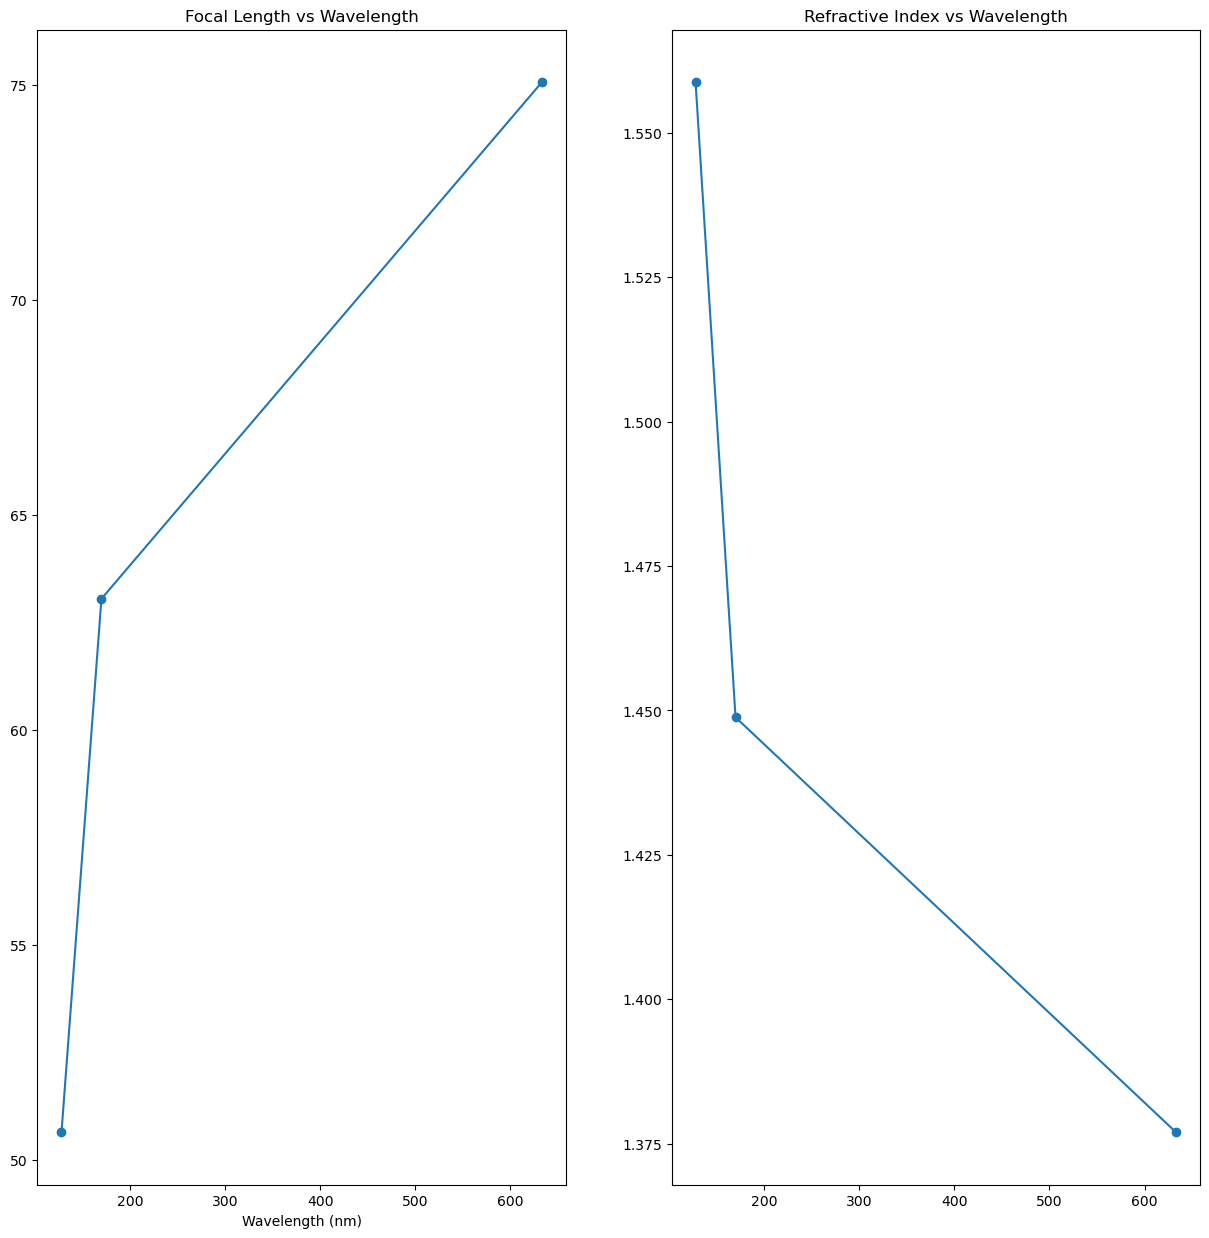

In [8]:
x=wavelengths.flatten()*1000
fig,axs=plt.subplots(1,2,sharex=True,figsize=(15,15))

axs[0].set_title("Focal Length vs Wavelength")
axs[0].plot(x,FocalLengths,marker="o")
axs[0].set_xlabel("Wavelength (nm)")
axs[1].set_title("Refractive Index vs Wavelength")
axs[1].plot(x,MgFloride,marker="o")


In [9]:
print(MgFloride)

[1.55878259 1.44882398 1.37698113]


In [10]:
## Magnefication Calculations
Mag=lambda f,d:f/(f-d) # using focal length

Magnification= lambda ObjDistance,ImageDistance:-(ImageDistance)/ObjDistance

In [11]:
HalfLens1Thicknes=5/2 ## mm
HalfLens2Thicknes=3.4/2 ## mm

In [39]:
# Magnefication Due to Lens1 From EL to II
ObjectDistanceLens1=330+HalfLens1Thicknes
ImageDistanceLens1=63+HalfLens1Thicknes
# Magnefication Due to Lens2 From II to Camera
#https://docs.google.com/spreadsheets/d/1aVq78DYm9pf8ov7MYV5Q03S6yrJ8tADe1XiPImRjmP4/edit#gid=130085331
CmountDistance=17.526 # https://www.edmundoptics.com/knowledge-center/application-notes/imaging/lens-mounts/#:~:text=The%20C%2DMount%20flange%20distance,flange%20distance%20of%2012.526mm.
Lens2FocalLength=49.8 # mm
ObjectDistanceLens2=197+HalfLens2Thicknes
ImageDistanceLens2=46.6+HalfLens2Thicknes+CmountDistance  




In [40]:
MagLens1=Magnification(ObjectDistanceLens1,ImageDistanceLens1)
MagLens2=Magnification(ObjectDistanceLens2,ImageDistanceLens2)

In [41]:

print(1/(MagLens1*MagLens2))

15.323245206017342


In [35]:
print(1/MagLens2)

-3.018564093215446


In [16]:
FocalLengths

array([50.64581594, 63.05367195, 75.07007124])